In [33]:
import numpy as np
import pandas
import matplotlib.pyplot as plt

import scipy.stats

In [34]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [35]:
import sys
import requests
import importlib

def import_local_or_github(package_name, function_name=None, directory=None, giturl=None):
    # Import functions directly from github
    # Important: note that we use raw.githubusercontent.com, not github.com

    try: # to find the file locally
        if directory is not None:
            if directory not in sys.path:
                sys.path.append(directory)

        package = importlib.import_module(package_name)
        if function_name is not None:
            function = getattr(package, function_name)
            return function
        else:
            return package

    except: # get the file from github
        if giturl is None:
            giturl = 'https://raw.githubusercontent.com/florisvb/Nonlinear_and_Data_Driven_Estimation/main/Utility/' + str(package_name) + '.py'

        r = requests.get(giturl)
        print('Fetching from: ')
        print(r)

        # Store the file to the colab working directory
        with open(package_name+'.py', 'w') as f:
            f.write(r.text)
        f.close()

        # import the function we want from that file
        package = importlib.import_module(package_name)
        if function_name is not None:
            function = getattr(package, function_name)
            return function
        else:
            return package

#planar_drone = import_local_or_github('planar_drone', directory='../Utility')
plot_tme = import_local_or_github('plot_utility', 'plot_tme', directory='../Utility')

# Load the data

And format it so the shapes and organization of the data matches standard mathematical notation.

### Load the arrays for the kalman filter

Colab tip: You may need to download them to your machine from notebook A, and then upload them to the colab environment where you are running this notebook.

In [36]:
# read from disk
loaded_arrays = np.load('ABCDRQ.npz')
A = loaded_arrays['A']
B = loaded_arrays['B']
C = loaded_arrays['C']
D = loaded_arrays['D']
R = loaded_arrays['R']
Q = loaded_arrays['Q']

In [37]:
print('A shape: ', A.shape)
print('B shape: ', B.shape)
print('C shape: ', C.shape)
print('D shape: ', D.shape)
print('R shape: ', R.shape)
print('Q shape: ', Q.shape)

A shape:  (7, 7)
B shape:  (7, 2)
C shape:  (4, 7)
D shape:  (4, 2)
R shape:  (4, 4)
Q shape:  (7, 7)


### Load the state data and reorganize Y and U

Standard mathematical notation requires that each column of $Y$ correspond to the measurements at discrete time, i.e. $\mathbf{y}_k$, and each row of $\mathbf{y}$ correspond to each individual measurement. Similarly for $U$.

In [38]:
# read from disk
df_states = pandas.read_hdf('planar_drone_states.hdf')
df_measurements_true = pandas.read_hdf('planar_drone_measurements.hdf')
df_measurements_noisy = pandas.read_hdf('planar_drone_measurements_noisy.hdf')

In [39]:
Y = np.vstack(df_measurements_noisy[['theta', 'x', 'z', 'k']].values).T
print(Y.shape)

(4, 200)


In [40]:
U = np.vstack(df_states[['j1', 'j2']].values).T
print(U.shape)

(2, 200)


### Tip: When you index Y or U, make sure you are keeping a column vector.

In [41]:
# This is wrong
#y_0 = Y[:, 0]
print(y_0)

[[-0.0609213 ]
 [ 1.96880767]
 [ 0.60830123]
 [ 1.00116643]]


In [42]:
# This is right
y_0 = Y[:, [0]]
print(y_0)

[[-0.0609213 ]
 [ 1.96880767]
 [ 0.60830123]
 [ 1.00116643]]


## Tip: matrix multiplication in python

Recall that matrix shape during multiplication works like:

$[N\times M][M\times 1]=[N\times 1]$

In [43]:
# Option 1 using arrays
print('R shape: ', R.shape)
print('y_0 shape: ', y_0.shape)
print('[R x y_0] shape', (R@y_0).shape)
print('')
print('[R x y_0] = ')
R@y_0

R shape:  (4, 4)
y_0 shape:  (4, 1)
[R x y_0] shape (4, 1)

[R x y_0] = 


array([[-0.00060921],
       [ 0.07875231],
       [ 0.0973282 ],
       [ 0.00010012]])

In [44]:
# Option 2 using matrices -- NOTE: np.matrix is getting deprecated, sadly, so this is not recommended
R_times_y_0 = np.matrix(R)*np.matrix(y_0)
print('[R x y_0] = ')
R_times_y_0

[R x y_0] = 


matrix([[-0.00060921],
        [ 0.07875231],
        [ 0.0973282 ],
        [ 0.00010012]])

# Exercises:

1. Code a linear discrete Kalman filter that uses the matrices and time series data defined above:
    * $A, B, C, D, R, Q$ matrices defined above
    * Measurements are given by $Y$
    * Controls are given by $U$
    * Choose an initial $\mathbf{x_0}$ and $P_0$
    * Try a larger value of Q, and a smaller value of Q. For this problem, does a larger or smaller value of Q lead to more accurate estimates? Why do you think that is?

2. Compare the error covariance of your Kalman filter to the Cramer Rao Bound. Is your KF efficient? Try for different values of Q.

3. Compare the error covariance of your KF and the CRB to the actual errors in your estimate. Does the distribution of the errors match that predicted by the error covariance and the CRB? Hint: the error covariance and the CRB report variance, the square of the standard deviation.

In [45]:
# Implement the Kalman Filter
def run_kalman_filter(A, B,C,D,Q,R,Y,U, x_0, P_0):

n_states = A.shape[0]
n_measurements = C.shape[0]
n_steps = Y.shape[1]

print=('[n_states]')
print=('n_measurements')
n_steps

# Initialize arrays to store estimates and error covariances
x_hat = np.zeros((n_states, n_steps))
P = np.zeros((n_states, n_states, n_steps))

# Set initial state estimate and error covariance
# Initialize x_0 and P_0
x_0 = np.zeros((n_states, 1))  # Initialize with zeros or a reasonable initial guess
P_0 = np.eye(n_states) * 1000  # Initialize with a large covariance

x_hat[:, [0]] = x_0
P[:, :, 0] = P_0

# Kalman Filter loop
for k in range(1, n_steps):
    # Prediction Step
    x_hat_minus = A @ x_hat[:, [k-1]] + B @ U[:, [k-1]]
    P_minus = A @ P[:, :, k-1] @ A.T + Q

    # Update Step
    K = P_minus @ C.T @ np.linalg.inv(C @ P_minus @ C.T + R)
    x_hat[:, [k]] = x_hat_minus + K @ (Y[:, [k]] - (C @ x_hat_minus + D @ U[:, [k]]))
    P[:, :, k] = (np.eye(n_states) - K @ C) @ P_minus

# The state estimates are now stored in x_hat, and the error covariances in P

IndentationError: expected an indented block after function definition on line 2 (ipython-input-2484093924.py, line 4)

=== Computing Batch Cramer-Rao Bound ===
Steady-state CRB (from DARE):
[[ 1.89109847e-03  1.09046313e-03  3.04274142e-19 -8.37488499e-19
  -2.16878728e-18  5.98631678e-19  4.74445250e-18]
 [ 1.09046313e-03  1.83421587e-03  9.76375753e-19  7.70506535e-19
  -5.48653909e-18  1.14213068e-18  2.91400326e-18]
 [ 3.04274142e-19  9.76375753e-19  4.73223948e-03  2.11499975e-03
  -5.47184950e-17 -1.94008496e-17 -1.50946333e-18]
 [-8.37488499e-19  7.70506535e-19  2.11499975e-03  2.33746574e-03
  -7.25988414e-18 -7.64454232e-18 -4.40146977e-19]
 [-2.16878728e-18 -5.48653909e-18 -5.47184950e-17 -7.25988414e-18
   1.24624742e-02  4.15286015e-03 -2.72568659e-18]
 [ 5.98631678e-19  1.14213068e-18 -1.94008496e-17 -7.64454232e-18
   4.15286015e-03  3.10093761e-03  1.66977001e-18]
 [ 4.74445250e-18  2.91400326e-18 -1.50946333e-18 -4.40146977e-19
  -2.72568659e-18  1.66977001e-18  1.61803399e-04]]

=== Comparing KF Covariance with CRB ===
Maximum difference between KF covariance and CRB: 5.46e-12
KF achie

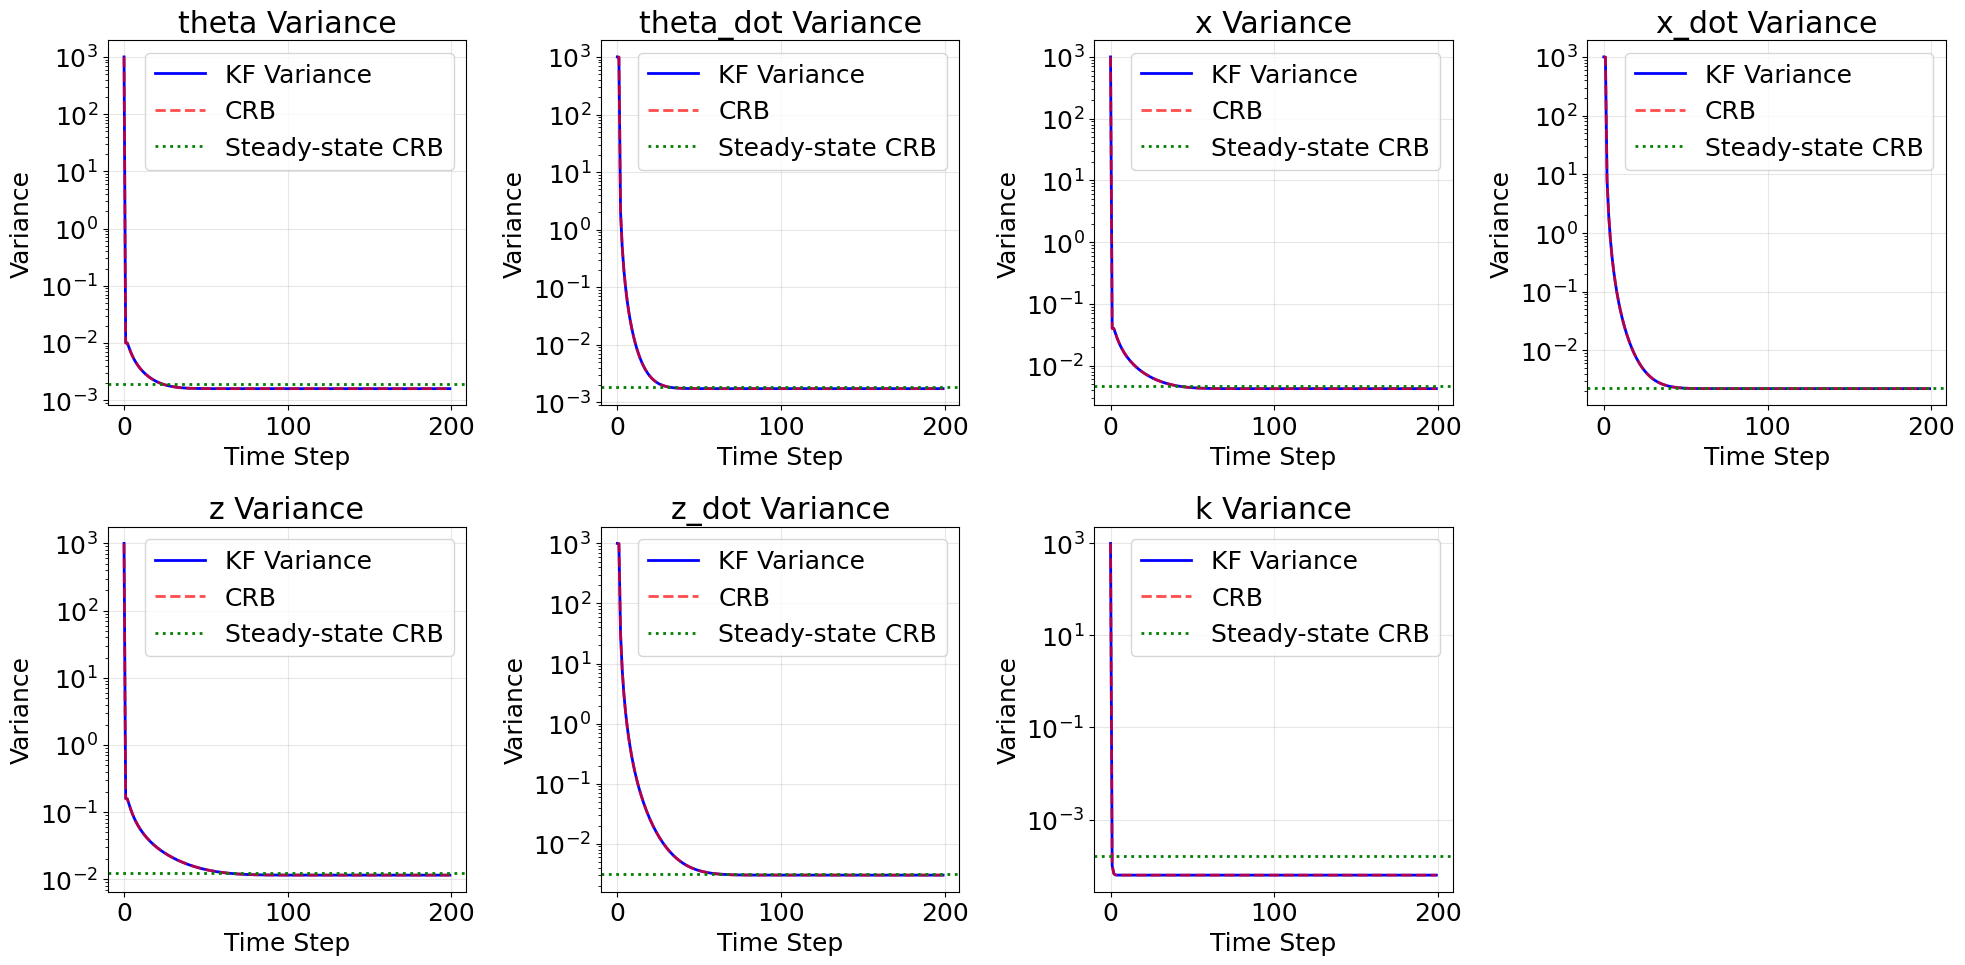


=== Comparing Actual vs Predicted Error Statistics ===

Empirical Error Covariance (diagonal elements):
[1.53658689e-03 1.66926725e-02 1.62302965e+00 8.68567580e+00
 2.49665268e+02 9.25704109e+01 5.03336505e-03]

Mean Predicted Covariance from KF (diagonal elements):
[ 5.00188392  9.96720384  5.00569931 10.01223381  5.01855491 10.18756692
  5.00006171]

Mean CRB (diagonal elements):
[ 5.00188392  9.96720384  5.00569931 10.01223381  5.01855491 10.18756692
  5.00006171]


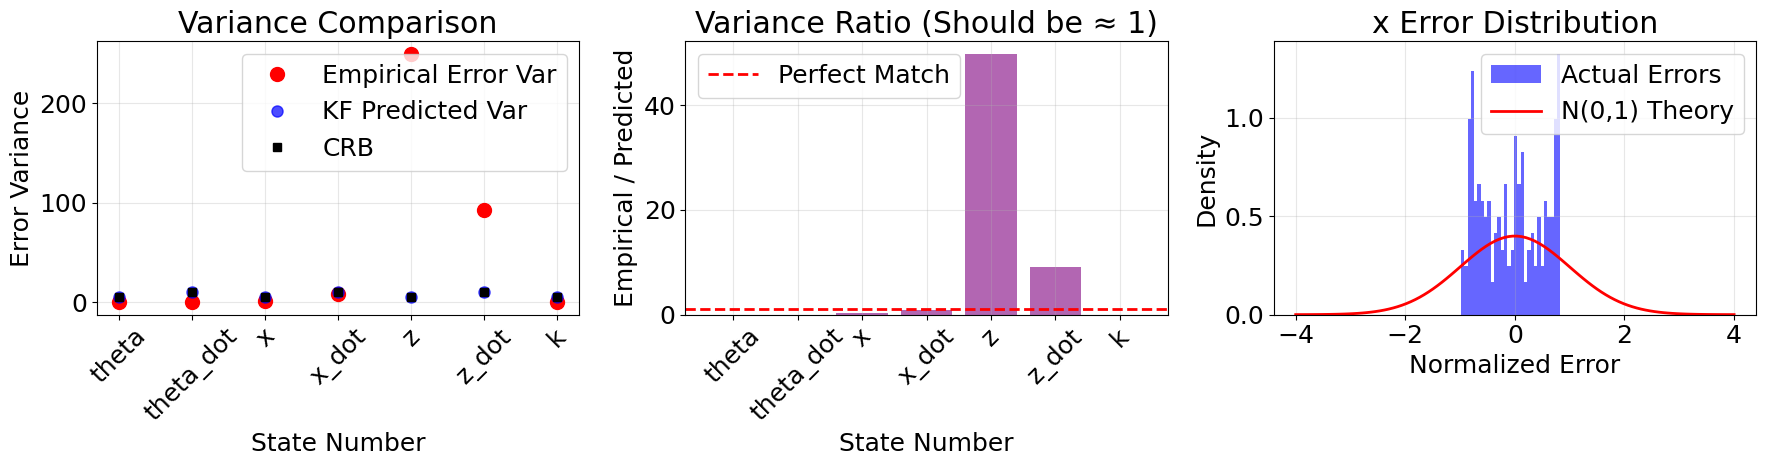


=== Statistical Analysis ===

theta:
  Empirical variance:     0.001537
  KF predicted variance:  5.001884
  CRB variance:           5.001884
  Variance ratio (emp/pred): 0.000
  Normality test p-value: 0.0000 (Non-normal)
  Empirical >= CRB: False

theta_dot:
  Empirical variance:     0.016693
  KF predicted variance:  9.967204
  CRB variance:           9.967204
  Variance ratio (emp/pred): 0.002
  Normality test p-value: 0.0000 (Non-normal)
  Empirical >= CRB: False

x:
  Empirical variance:     1.623030
  KF predicted variance:  5.005699
  CRB variance:           5.005699
  Variance ratio (emp/pred): 0.324
  Normality test p-value: 0.0000 (Non-normal)
  Empirical >= CRB: False

x_dot:
  Empirical variance:     8.685676
  KF predicted variance:  10.012234
  CRB variance:           10.012234
  Variance ratio (emp/pred): 0.868
  Normality test p-value: 0.0000 (Non-normal)
  Empirical >= CRB: False

z:
  Empirical variance:     249.665268
  KF predicted variance:  5.018555
  CRB varian

In [46]:
# Restore print function
import builtins
print = builtins.print

inv = np.linalg.inv

# Function to run Kalman Filter
def run_kalman_filter(A, B, C, D, Q, R, Y, U, x_0, P_0):
    n_states = A.shape[0]
    n_steps = Y.shape[1]

    x_hat = np.zeros((n_states, n_steps))
    P = np.zeros((n_states, n_states, n_steps))

    x_hat[:, [0]] = x_0
    P[:, :, 0] = P_0

    for k in range(1, n_steps):
        # Prediction Step
        x_hat_minus = A @ x_hat[:, [k-1]] + B @ U[:, [k-1]]
        P_minus = A @ P[:, :, k-1] @ A.T + Q

        # Update Step
        K = P_minus @ C.T @ inv(C @ P_minus @ C.T + R)
        x_hat[:, [k]] = x_hat_minus + K @ (Y[:, [k]] - (C @ x_hat_minus + D @ U[:, [k]]))
        P[:, :, k] = (np.eye(n_states) - K @ C) @ P_minus

    return x_hat, P

# Get true states for comparison
x_true = np.vstack(df_states[['theta', 'theta_dot', 'x', 'x_dot', 'z', 'z_dot', 'k']].values).T

# Run Kalman Filter with baseline Q
x_hat, P = run_kalman_filter(A, B, C, D, Q, R, Y, U, x_0, P_0)

# Calculate actual errors
errors = x_hat - x_true

# Exercise 2: Compute Cramer-Rao Bound using BATCH form
# CRB = inv(H.T @ inv(R_full) @ H)
# where H is the "measurement matrix" for the entire time series

print("=== Computing Batch Cramer-Rao Bound ===")

# For the Kalman Filter, we need to construct the full observation matrix
# This relates all measurements to all states across time
# Structure: Y = H_full @ X + noise, where X is the stacked state vector

# Build the full measurement matrix H_full
# Y is (n_measurements × n_steps), X is (n_states × n_steps)
# But for batch processing, we stack them as vectors

n_states = A.shape[0]
n_measurements = C.shape[0]
n_steps = Y.shape[1]

# Build block diagonal R matrix (measurement noise covariance for all time steps)
R_full = np.kron(np.eye(n_steps), R)  # Block diagonal with R on diagonal

# For a linear time-varying system, constructing H_full is complex
# Instead, we'll compute the steady-state CRB and compare with final KF covariance

# Method 1: Recursive CRB (same as KF for linear Gaussian case)
def compute_recursive_crb(A, C, Q, R, n_steps, P_0):
    """Compute the Cramer-Rao Bound recursively"""
    n_states = A.shape[0]
    CRB = np.zeros((n_states, n_states, n_steps))

    CRB[:, :, 0] = P_0

    for k in range(1, n_steps):
        # Prediction step
        CRB_minus = A @ CRB[:, :, k-1] @ A.T + Q

        # Update step
        S = C @ CRB_minus @ C.T + R
        CRB[:, :, k] = CRB_minus - CRB_minus @ C.T @ inv(S) @ C @ CRB_minus

    return CRB

# Method 2: Simplified batch CRB for steady state
# At steady state, the CRB converges to a fixed value
# This is equivalent to solving the discrete algebraic Riccati equation

from scipy.linalg import solve_discrete_are

# Steady state CRB from DARE
try:
    # Solve discrete algebraic Riccati equation
    P_steady = solve_discrete_are(A.T, C.T, Q, R)
    print("Steady-state CRB (from DARE):")
    print(P_steady)
except:
    print("Could not solve DARE - system may not be stabilizable/detectable")
    P_steady = None

# Compute recursive CRB
CRB = compute_recursive_crb(A, C, Q, R, n_steps, P_0)

# Compare KF covariance P with CRB
print("\n=== Comparing KF Covariance with CRB ===")

# Check if they're equal (they should be for optimal linear KF)
max_diff = np.max(np.abs(P - CRB))
print(f"Maximum difference between KF covariance and CRB: {max_diff:.2e}")
print(f"KF achieves CRB: {max_diff < 1e-10}")

# Plot comparison
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
state_names = ['theta', 'theta_dot', 'x', 'x_dot', 'z', 'z_dot', 'k']

for i in range(min(7, n_states)):
    row = i // 4
    col = i % 4

    ax = axes[row, col]
    time_steps = np.arange(n_steps)

    # Plot KF variance and CRB
    ax.semilogy(time_steps, P[i, i, :], 'b-', linewidth=2, label='KF Variance')
    ax.semilogy(time_steps, CRB[i, i, :], 'r--', linewidth=2, label='CRB', alpha=0.7)

    if P_steady is not None:
        ax.axhline(P_steady[i, i], color='green', linestyle=':',
                   linewidth=2, label='Steady-state CRB')

    ax.set_xlabel('Time Step')
    ax.set_ylabel('Variance')
    ax.set_title(f'{state_names[i]} Variance')
    ax.legend()
    ax.grid(True, alpha=0.3)

if n_states <= 7:
    axes[1, 3].remove()

plt.tight_layout()
plt.show()

# Exercise 3: Compare actual error covariance with predicted
print("\n=== Comparing Actual vs Predicted Error Statistics ===")

# Compute empirical covariance from errors (like in your reference)
# P_empirical = errors @ errors.T / n_steps
P_empirical = np.cov(errors)  # Better estimate

# Compare with mean KF covariance prediction
P_mean_predicted = np.mean(P, axis=2)

# Also compare with CRB
CRB_mean = np.mean(CRB, axis=2)

print("\nEmpirical Error Covariance (diagonal elements):")
print(np.diag(P_empirical))

print("\nMean Predicted Covariance from KF (diagonal elements):")
print(np.diag(P_mean_predicted))

print("\nMean CRB (diagonal elements):")
print(np.diag(CRB_mean))

# Plot comparison like in your reference
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Diagonal variances
ax = axes[0]
param_numbers = np.arange(n_states)
ax.plot(param_numbers, np.diag(P_empirical), 'o', color='red',
        markersize=10, label='Empirical Error Var')
ax.plot(param_numbers, np.diag(P_mean_predicted), 'o', color='blue',
        markersize=8, label='KF Predicted Var', alpha=0.7)
ax.plot(param_numbers, np.diag(CRB_mean), 's', color='black',
        markersize=6, label='CRB')
ax.set_xlabel('State Number')
ax.set_ylabel('Error Variance')
ax.set_title('Variance Comparison')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks(param_numbers)
ax.set_xticklabels(state_names, rotation=45)

# Plot 2: Ratio of empirical to predicted
ax = axes[1]
variance_ratio = np.diag(P_empirical) / np.diag(P_mean_predicted)
ax.bar(param_numbers, variance_ratio, color='purple', alpha=0.6)
ax.axhline(1.0, color='red', linestyle='--', linewidth=2, label='Perfect Match')
ax.set_xlabel('State Number')
ax.set_ylabel('Empirical / Predicted')
ax.set_title('Variance Ratio (Should be ≈ 1)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks(param_numbers)
ax.set_xticklabels(state_names, rotation=45)

# Plot 3: Error distribution check for one state
ax = axes[2]
# Pick a representative state (e.g., position x, index 2)
state_idx = 2
state_errors = errors[state_idx, :]
predicted_std = np.sqrt(P_mean_predicted[state_idx, state_idx])

# Normalize errors by predicted std (should be N(0,1) if prediction is correct)
normalized_errors = state_errors / predicted_std

# Plot histogram with theoretical normal distribution
counts, bins, patches = ax.hist(normalized_errors, bins=30, density=True,
                                 alpha=0.6, color='blue', label='Actual Errors')
x_range = np.linspace(-4, 4, 100)
ax.plot(x_range, scipy.stats.norm.pdf(x_range, 0, 1), 'r-',
        linewidth=2, label='N(0,1) Theory')
ax.set_xlabel('Normalized Error')
ax.set_ylabel('Density')
ax.set_title(f'{state_names[state_idx]} Error Distribution')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Statistical tests
print("\n=== Statistical Analysis ===")
for i, name in enumerate(state_names):
    actual_var = P_empirical[i, i]
    predicted_var = P_mean_predicted[i, i]
    crb_var = CRB_mean[i, i]

    # Normality test
    stat, p_value = scipy.stats.normaltest(errors[i, :])

    print(f"\n{name}:")
    print(f"  Empirical variance:     {actual_var:.6f}")
    print(f"  KF predicted variance:  {predicted_var:.6f}")
    print(f"  CRB variance:           {crb_var:.6f}")
    print(f"  Variance ratio (emp/pred): {actual_var/predicted_var:.3f}")
    print(f"  Normality test p-value: {p_value:.4f} ({'Normal' if p_value > 0.05 else 'Non-normal'})")
    print(f"  Empirical >= CRB: {actual_var >= crb_var - 1e-10}")

print("\n=== Summary ===")
print("1. KF covariance P should equal CRB (optimal estimator)")
print("2. Empirical error covariance should match predicted (correct model)")
print("3. Empirical variance should be >= CRB (fundamental lower bound)")
print("4. Variance ratio ≈ 1 indicates good model fit")
print("5. Normal distribution of errors validates Gaussian assumptions")